In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')


In [2]:
N              = 50
T_c            = 2 / np.log(1 + np.sqrt(2))
BURN_IN        = 250
N_TRIALS       = 3
MEASURE_SWEEPS = 500


In [3]:
def initialize(N, p_positive):
    return np.random.choice([-1, 1], size=(N, N), p=[1 - p_positive, p_positive])


In [4]:
def metropolis_sweep(lattice, T, J=1.0, B=0.0):
    Lx, Ly = lattice.shape
    beta = 1.0 / T
    for _ in range(Lx * Ly):
        i = np.random.randint(0, Lx)
        j = np.random.randint(0, Ly)
        spin = lattice[i, j]
        neighbours = (
            lattice[(i-1) % Lx, j] + lattice[(i+1) % Lx, j] +
            lattice[i, (j-1) % Ly] + lattice[i, (j+1) % Ly]
        )
        dE = 2.0 * spin * (J * neighbours + B)
        if dE <= 0 or np.random.random() < np.exp(-beta * dE):
            lattice[i, j] *= -1
    return lattice


In [5]:
data       = np.load('ising_data.npz')
T_range    = data['T_range']
mean_M_arr = data['mean_M_arr']
std_M_arr  = data['std_M_arr']


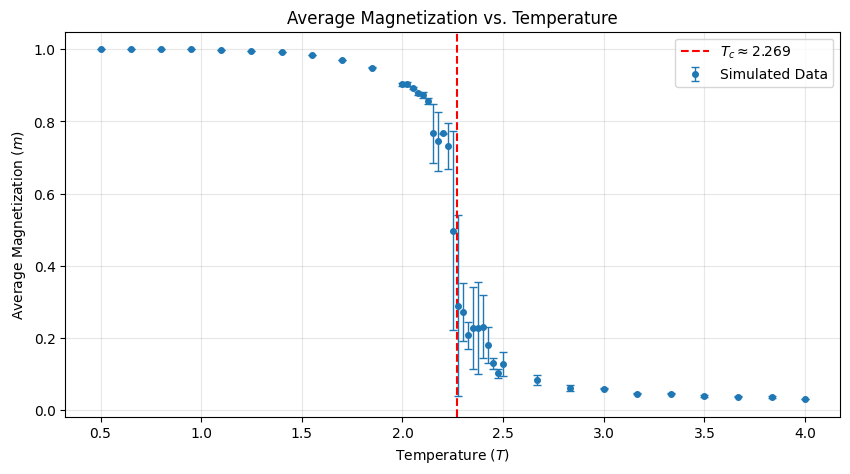

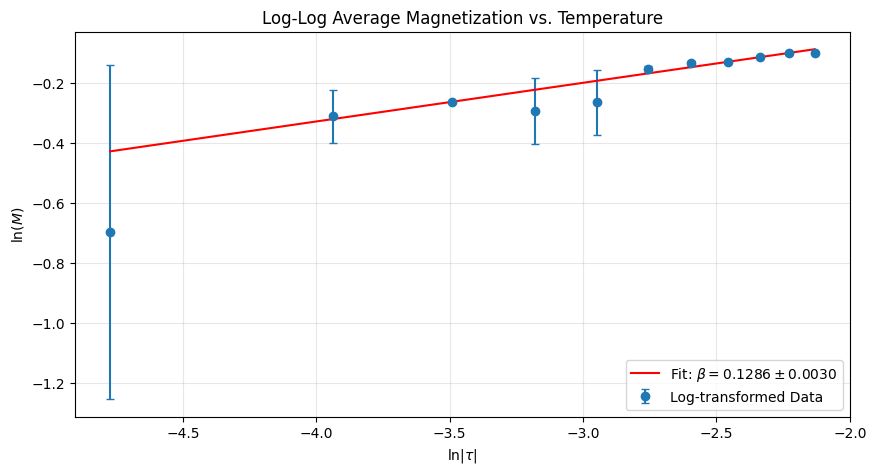

Calculated Beta: 0.1286 +/- 0.0030
Theoretical Beta: 0.125


In [6]:
plt.figure(figsize=(10, 5))
plt.errorbar(T_range, mean_M_arr, yerr=std_M_arr, fmt='o', markersize=4,
             capsize=3, elinewidth=1, label='Simulated Data')
plt.axvline(T_c, color='red', linestyle='--', label=f'$T_c \\approx {T_c:.3f}$')
plt.xlabel('Temperature ($T$)')
plt.ylabel('Average Magnetization ($m$)')
plt.title('Average Magnetization vs. Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

mask   = (T_range < T_c) & (T_range > 1.96)
T_filt = T_range[mask]
M_filt = mean_M_arr[mask]
dM_filt = std_M_arr[mask]

tau    = (T_c - T_filt) / T_c
x_log  = np.log(tau)
y_log  = np.log(M_filt)
dy_log = dM_filt / M_filt

def linear_model(x, beta, C):
    return beta * x + C

popt, pcov = curve_fit(linear_model, x_log, y_log, sigma=dy_log, absolute_sigma=True)
beta_measured, intercept = popt
beta_error = np.sqrt(pcov[0, 0])

plt.figure(figsize=(10, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', capsize=3, label='Log-transformed Data')
plt.plot(x_log, linear_model(x_log, *popt), color='red',
         label=f'Fit: $\\beta = {beta_measured:.4f} \\pm {beta_error:.4f}$')
plt.xlabel('$\\ln|\\tau|$')
plt.ylabel('$\\ln(M)$')
plt.title('Log-Log Average Magnetization vs. Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Calculated Beta: {beta_measured:.4f} +/- {beta_error:.4f}')
print(f'Theoretical Beta: 0.125')


In [7]:
B_range       = np.linspace(-0.5, 0.5, 41)
mean_M_B      = []
std_error_M_B = []

for B in B_range:
    print(f'Running B = {B:.3f}')
    trial_means = []
    for trial in range(N_TRIALS):
        p_positive = 0.6 if B > 0 else (0.4 if B < 0 else 0.5)
        lattice = initialize(N, p_positive)
        for _ in range(BURN_IN):
            metropolis_sweep(lattice, T_c, B=B)
        m_samples = []
        for _ in range(MEASURE_SWEEPS):
            metropolis_sweep(lattice, T_c, B=B)
            m_samples.append(np.mean(lattice))
        trial_means.append(np.mean(m_samples))
    mean_M_B.append(np.mean(trial_means))
    std_error_M_B.append(np.std(trial_means) / np.sqrt(N_TRIALS))

mean_M_B      = np.array(mean_M_B)
std_error_M_B = np.array(std_error_M_B)

np.savez('ising_delta_data.npz',
         B_range=B_range, mean_M_B=mean_M_B, std_error_M_B=std_error_M_B)
print('Saved ising_delta_data.npz')


Running B = -0.500
Running B = -0.475
Running B = -0.450
Running B = -0.425
Running B = -0.400
Running B = -0.375
Running B = -0.350
Running B = -0.325


KeyboardInterrupt: 

In [9]:
data          = np.load('ising_delta_data.npz')
B_range       = data['B_range']
mean_M_B      = data['mean_M_B']
std_error_M_B = data['std_error_M_B']


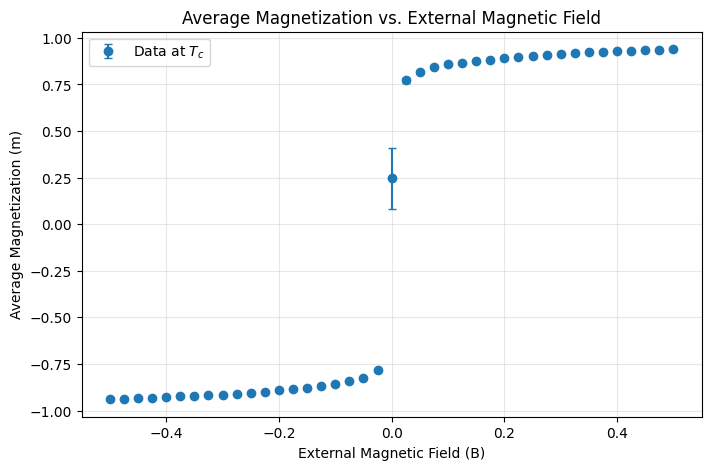

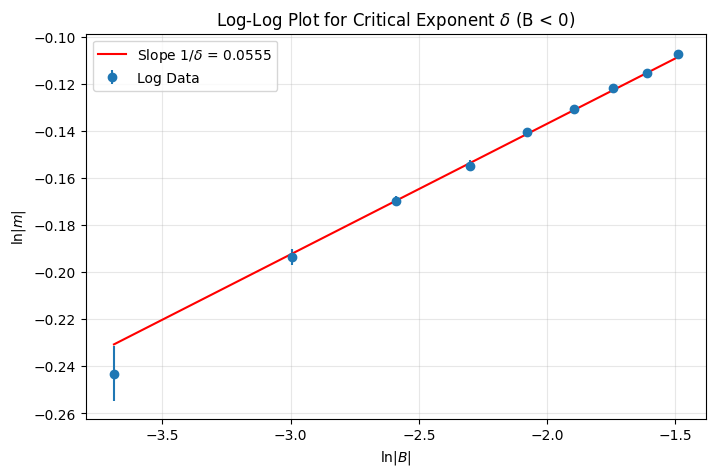

Calculated Delta: 18.0229 +/- 0.3613
Theoretical Delta: 15.0


In [10]:
plt.figure(figsize=(8, 5))
plt.errorbar(B_range, mean_M_B, yerr=std_error_M_B, fmt='o', capsize=3, label='Data at $T_{c}$')
plt.xlabel('External Magnetic Field (B)')
plt.ylabel('Average Magnetization (m)')
plt.title('Average Magnetization vs. External Magnetic Field')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

mask   = (B_range < 0) & (B_range > -0.25)
B_filt = np.abs(B_range[mask])
M_filt = np.abs(mean_M_B[mask])
dM_filt = std_error_M_B[mask]

x_log  = np.log(B_filt)
y_log  = np.log(M_filt)
dy_log = dM_filt / M_filt

def linear_fit(x, k, c):
    return k * x + c

popt, pcov = curve_fit(linear_fit, x_log, y_log, sigma=dy_log, absolute_sigma=True)
slope_k, intercept = popt
slope_err = np.sqrt(pcov[0, 0])
delta_val = 1 / slope_k
delta_err = slope_err / slope_k**2

plt.figure(figsize=(8, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', label='Log Data')
plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\\delta$ = {slope_k:.4f}')
plt.xlabel('$\\ln|B|$')
plt.ylabel('$\\ln|m|$')
plt.title('Log-Log Plot for Critical Exponent $\\delta$ (B < 0)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Calculated Delta: {delta_val:.4f} +/- {delta_err:.4f}')
print(f'Theoretical Delta: 15.0')


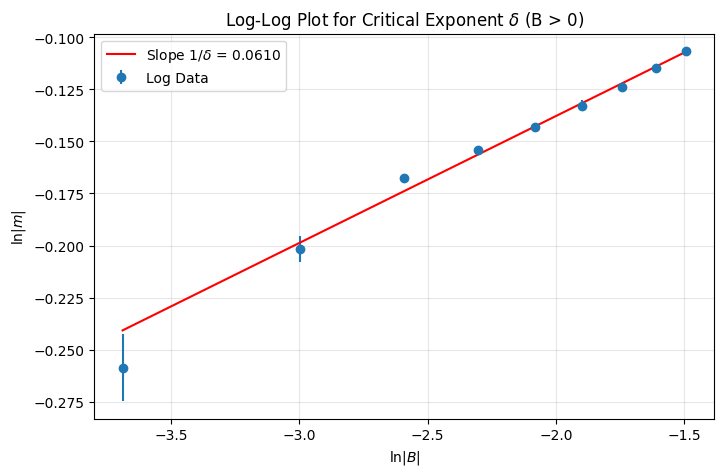

Calculated Delta: 16.4022 +/- 0.1837
Theoretical Delta: 15.0


In [11]:
mask   = (B_range > 0) & (B_range < 0.25)
B_filt = np.abs(B_range[mask])
M_filt = np.abs(mean_M_B[mask])
dM_filt = std_error_M_B[mask]

x_log  = np.log(B_filt)
y_log  = np.log(M_filt)
dy_log = dM_filt / M_filt

popt, pcov = curve_fit(linear_fit, x_log, y_log, sigma=dy_log, absolute_sigma=True)
slope_k, intercept = popt
slope_err = np.sqrt(pcov[0, 0])
delta_val = 1 / slope_k
delta_err = slope_err / slope_k**2

plt.figure(figsize=(8, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', label='Log Data')
plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\\delta$ = {slope_k:.4f}')
plt.xlabel('$\\ln|B|$')
plt.ylabel('$\\ln|m|$')
plt.title('Log-Log Plot for Critical Exponent $\\delta$ (B > 0)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Calculated Delta: {delta_val:.4f} +/- {delta_err:.4f}')
print(f'Theoretical Delta: 15.0')
